<a href="https://colab.research.google.com/github/KaitlynYip/Multi-Clip-ZeroShot-Model/blob/main/zero_of_Dinov2_of_clipZeroshot1000_General_pascal_single_label.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Note: The SyntaxError you encountered was in cell LUA6kIVPOecD.
# Please change 'from google.colab import runtime import runtime' to 'from google.colab import runtime' in that cell.
# Verify GPU (run this FIRST after reconnecting)
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name     :", torch.cuda.get_device_name(0))
    print("GPU memory   :", f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("GPU count    :", torch.cuda.device_count())
else:
    print("❌ GPU not detected! Go back to Step 1.")

CUDA available: True
GPU name     : Tesla T4
GPU memory   : 15.6 GB
GPU count    : 1


In [2]:
# Click: Runtime → Change runtime type → Hardware accelerator → GPU → Save
# Then run this cell to confirm GPU is active

import torch
print("CUDA available :", torch.cuda.is_available())
print("GPU name       :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available : True
GPU name       : Tesla T4


In [3]:
!pip install -q --no-cache-dir \
    "open-clip-torch==2.24.0" \
    "ftfy" "regex" "tqdm" "seaborn" "scikit-learn" "matplotlib"

print("All packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 180.2 MB/s eta 0:00:00
All packages installed!


In [4]:
import torch
import open_clip
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torchvision import datasets
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on → {device.upper()} {torch.cuda.get_device_name(0) if device=='cuda' else ''}")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Running on → CUDA Tesla T4


In [5]:
# PASCAL VOC 2012
# download the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gopalbhattrai/pascal-voc-2012-dataset")

print("Path to dataset files:",path)




Using Colab cache for faster access to the 'pascal-voc-2012-dataset' dataset.
Mounting files to /kaggle/input/pascal-voc-2012-dataset...


KeyboardInterrupt: 

In [6]:
#change dataset into csv file
import os
import xml.etree.ElementTree as ET
from tqdm.auto import tqdm
import pandas as pd

# Correct paths for the train+val part
IMAGE_DIR    = "/content/sample_data/kaggle/input/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages"
ANNO_DIR     = "/content/sample_data/kaggle/input/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/Annotations"

xml_files = sorted([f for f in os.listdir(ANNO_DIR) if f.endswith('.xml')])

data = []
for xml_name in tqdm(xml_files, desc="Converting train+val to CSV"):
    img_name = xml_name.replace(".xml", ".jpg")
    img_path = os.path.join(IMAGE_DIR, img_name)
    xml_path = os.path.join(ANNO_DIR, xml_name)

    tree = ET.parse(xml_path)
    labels = [obj.find("name").text.strip() for obj in tree.findall("object")]

    data.append({
        "image_path": img_path,
        "labels": ",".join(labels),
        "num_objects": len(labels)
    })

df = pd.DataFrame(data)
csv_path = "/content/pascal voc 2012.csv"
df.to_csv(csv_path, index=False)
print("Saved →", csv_path)

print(f"Done! {len(df)} images → {csv_path}")
df.head(10)


Converting train+val to CSV:   0%|          | 0/17125 [00:00<?, ?it/s]

Saved → /content/pascal voc 2012.csv
Done! 17125 images → /content/pascal voc 2012.csv


,image_path,labels,num_objects
0,/content/sample_data/kaggle/input/pascal-voc-2...,person,1
1,/content/sample_data/kaggle/input/pascal-voc-2...,"aeroplane,aeroplane,person,person",4
2,/content/sample_data/kaggle/input/pascal-voc-2...,"aeroplane,aeroplane,aeroplane",3
3,/content/sample_data/kaggle/input/pascal-voc-2...,tvmonitor,1
4,/content/sample_data/kaggle/input/pascal-voc-2...,"train,train",2
5,/content/sample_data/kaggle/input/pascal-voc-2...,"boat,boat",2
6,/content/sample_data/kaggle/input/pascal-voc-2...,"dog,chair",2
7,/content/sample_data/kaggle/input/pascal-voc-2...,bird,1
8,/content/sample_data/kaggle/input/pascal-voc-2...,"tvmonitor,tvmonitor",2
9,/content/sample_data/kaggle/input/pascal-voc-2...,train,1


In [7]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU - Change Runtime Type to GPU!")

!pip install -q --no-cache-dir open-clip-torch ftfy regex tqdm seaborn scikit-learn pandas

GPU: Tesla T4


In [8]:
# =============================================
# CLIP Zero-Shot on PASCAL VOC 2012 (Single Label per Image)
# =============================================

# 1. Install dependencies
!pip install -q --no-cache-dir \
    "open-clip-torch==2.24.0" ftfy regex tqdm seaborn scikit-learn matplotlib pandas kagglehub

import os
import xml.etree.ElementTree as ET
import pandas as pd
from tqdm.auto import tqdm
import torch
import open_clip
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device.upper()}")


Running on CUDA


In [9]:
# 3. Convert XML → CSV with ONE label per image (first object only)
print("Converting annotations to CSV (single label mode)...")
xml_files = sorted([f for f in os.listdir(ANNO_DIR) if f.endswith('.xml')])

data = []
for xml_name in tqdm(xml_files, desc="Parsing XML"):
    xml_path = os.path.join(ANNO_DIR, xml_name)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img_name = xml_name.replace(".xml", ".jpg")
    img_path = os.path.join(IMAGE_DIR, img_name)

    # Get all object names
    objects = [obj.find("name").text.strip() for obj in root.findall("object")]

    # Take ONLY the first object as the label for this image
    if objects:
        single_label = objects[0]
    else:
        single_label = "background"  # very rare case

    data.append({
        "image_path": img_path,
        "label": single_label,
        "num_objects": len(objects)
    })

df = pd.DataFrame(data)
csv_path = "/content/pascal_voc_2012_single_label.csv"
df.to_csv(csv_path, index=False)
print(f"Saved {len(df)} images → {csv_path}")

# Show class distribution
print("\nClass distribution (single label):")
print(df['label'].value_counts())

Converting annotations to CSV (single label mode)...


Parsing XML:   0%|          | 0/17125 [00:00<?, ?it/s]

Saved 17125 images → /content/pascal_voc_2012_single_label.csv

Class distribution (single label):
label
person         6890
dog            1204
cat            1047
car             785
bird            767
aeroplane       683
chair           547
train           533
horse           465
boat            462
bicycle         449
tvmonitor       439
motorbike       431
bus             405
sofa            392
bottle          391
sheep           344
cow             326
diningtable     287
pottedplant     278
Name: count, dtype: int64


In [ ]:
#train_dataset = VOCSingleLabelDataset(train_csv, class_to_idx, transform=preprocess)
#test_dataset  = VOCSingleLabelDataset(test_csv,  class_to_idx, transform=preprocess)

In [10]:
from sklearn.model_selection import train_test_split

# df must contain image paths and labels
# example columns: df["image_path"], df["label"]

# Step 1: train (70) vs temp (30)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# Step 2: split temp into validation and test (15/15)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 11987
Validation size: 2569
Test size: 2569


In [11]:
print(train_df["label"].value_counts(normalize=True))
print(val_df["label"].value_counts(normalize=True))
print(test_df["label"].value_counts(normalize=True))

label
person         0.402353
dog            0.070326
cat            0.061150
car            0.045800
bird           0.044799
aeroplane      0.039877
chair          0.031951
train          0.031117
horse          0.027113
boat           0.026946
bicycle        0.026195
tvmonitor      0.025611
motorbike      0.025194
bus            0.023692
bottle         0.022858
sofa           0.022858
sheep          0.020105
cow            0.019021
diningtable    0.016768
pottedplant    0.016268
Name: proportion, dtype: float64
label
person         0.402491
dog            0.070455
cat            0.061113
car            0.045932
bird           0.044764
aeroplane      0.040093
chair          0.031919
train          0.031141
horse          0.027248
boat           0.026859
bicycle        0.026469
tvmonitor      0.025691
motorbike      0.024912
bus            0.023355
sofa           0.022966
bottle         0.022577
sheep          0.019852
cow            0.019074
diningtable    0.016738
pottedplant    0.01

In [12]:
#split data
train_csv = "/content/pascal_voc_2012_train_70.csv"
val_csv = "/content/pascal_voc_2012_val_15.csv"
test_csv  = "/content/pascal_voc_2012_test_15.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)

import pandas as pd
import ast
import numpy as np

def fix_path(v):
    while isinstance(v, (list, tuple, np.ndarray)):
        v = v[0] if len(v) else None
    if isinstance(v, str):
        s = v.strip()
        if s.startswith("[") and s.endswith("]"):
            v = ast.literal_eval(s)
            while isinstance(v, (list, tuple, np.ndarray)):
                v = v[0] if len(v) else None
    return v

train_df = pd.read_csv(train_csv)
val_df  = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

train_df["image_path"] = train_df["image_path"].apply(fix_path)
val_df["image_path"]  = val_df["image_path"].apply(fix_path)
test_df["image_path"]  = test_df["image_path"].apply(fix_path)

train_csv_clean = "/content/pascal_voc_2012_train_70_clean.csv"
val_csv_clean  = "/content/pascal_voc_2012_val_15_clean.csv"
test_csv_clean  = "/content/pascal_voc_2012_test_15_clean.csv"

train_df.to_csv(train_csv_clean, index=False)
val_df.to_csv(val_csv_clean, index=False)
test_df.to_csv(test_csv_clean, index=False)

print("Saved:", train_csv_clean, val_csv_clean, test_csv_clean)

# === 3. Save the new splits ===
#train_csv = "/content/pascal_voc_2012_train_80.csv"
#test_csv  = "/content/pascal_voc_2012_test_20.csv"

#train_df.to_csv(train_csv, index=False)
#test_df.to_csv(test_csv, index=False)

#print(f"\nSaved training set ({len(train_df)} images) → {train_csv}")
#print(f"Saved testing set  ({len(test_df)} images)  → {test_csv}")

# === 4. Verify the split distributions ===
print("\n" + "="*60)
print("CLASS DISTRIBUTION AFTER SPLIT")
print("="*60)

# Combine for nice side-by-side view
dist_train = train_df['label'].value_counts().sort_index()
dist_val  = val_df['label'].value_counts().sort_index()
dist_test  = test_df['label'].value_counts().sort_index()

dist_df = pd.DataFrame({
    'Class': dist_train.index,
    'Train (70%)': dist_train.values,
    'Validation (15%)': dist_val.values,
    'Test (15%)': dist_test.values
})
dist_df['Train %'] = (dist_df['Train (70%)'] / len(train_df) * 100).round(2)
dist_df['Validation %']  = (dist_df['Validation (15%)'] / len(test_df) * 100).round(2)
dist_df['Test %']  = (dist_df['Test (15%)'] / len(test_df) * 100).round(2)

print(dist_df.to_string(index=False))

print(f"\nTotal training images: {len(train_df)}")
print(f"Total validation images : {len(val_df)}")
print(f"Total testing images : {len(test_df)}")

Saved:
/content/pascal_voc_2012_train_70.csv
/content/pascal_voc_2012_val_15.csv
/content/pascal_voc_2012_test_15.csv
Saved: /content/pascal_voc_2012_train_70_clean.csv /content/pascal_voc_2012_val_15_clean.csv /content/pascal_voc_2012_test_15_clean.csv

CLASS DISTRIBUTION AFTER SPLIT
      Class  Train (70%)  Validation (15%)  Test (15%)  Train %  Validation %  Test %
  aeroplane          478               103         102     3.99          4.01    3.97
    bicycle          314                68          67     2.62          2.65    2.61
       bird          537               115         115     4.48          4.48    4.48
       boat          323                69          70     2.69          2.69    2.72
     bottle          274                58          59     2.29          2.26    2.30
        bus          284                60          61     2.37          2.34    2.37
        car          549               118         118     4.58          4.59    4.59
        cat          733  

In [13]:
# 4. Define the 20 VOC classes (standard order)
classes = ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
           'bus', 'car', 'cat', 'chair', 'cow',
           'diningtable', 'dog', 'horse', 'motorbike', 'person',
           'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

class_to_idx = {c: i for i, c in enumerate(classes)}
NUM_CLASSES = len(classes)

In [14]:
# 5. Custom Dataset — single integer label
import ast
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class VOCSingleLabelDataset(Dataset):
    def __init__(self, csv_file, class_to_idx, transform=None):
        import pandas as pd
        self.df = pd.read_csv(csv_file)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def _to_single_path(self, v):
        # unwrap nested lists/tuples/arrays
        while isinstance(v, (list, tuple, np.ndarray)):
            if len(v) == 0:
                return None
            v = v[0]

        # parse stringified list: "['/path.jpg']"
        if isinstance(v, str):
            s = v.strip()
            if s.startswith("[") and s.endswith("]"):
                v = ast.literal_eval(s)
                while isinstance(v, (list, tuple, np.ndarray)):
                    if len(v) == 0:
                        return None
                    v = v[0]
        return v

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = self._to_single_path(row["image_path"])

        if not isinstance(img_path, str):
            raise TypeError(
                f"Bad image_path at idx={idx}. "
                f"type={type(row['image_path'])}, value={row['image_path']}"
            )

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label_str = row["label"]
        label_id = self.class_to_idx[label_str]
        return image, label_id

    def __len__(self):
        return len(self.df)


In [15]:
# 7. Dataset & DataLoader
#dataset = VOCSingleLabelDataset(csv_path, transform=preprocess)
#loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)

# Use only the 20% test set for final evaluation
# test_csv = "/content/pascal_voc_2012_test_20.csv"  # from your train_test_split

# test_dataset = VOCSingleLabelDataset(test_csv, transform=preprocess)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)


# 8. Best 9 prompt templates (gives ~91–92% on CIFAR-10, works great on VOC too)
templates = [
    "a photo of a {}.",
    "a blurry photo of a {}.",
    "a photo of a small {}.",
    "a photo of a large {}.",
    "a cropped photo of the {}.",
    "a bright photo of a {}.",
    "a dark photo of a {}.",
    "a pixelated photo of a {}.",
    "a good photo of the {}.",
    "a high resolution photo of a {}.",
    "a clear photo of a {}.",
    "a sharp photo of the {}.",
    "a close-up photo of a {}.",
    "a low quality photo of a {}.",
    "an example of a {}.",
    "a zoomed-in photo of a {}.",
    "a wide-angle photo of a {}.",
    "photo showing a {}.",
    "this is a photo of a {}.",
    "a photo of a {} in a scene.",
    "a photo of a {} vehicle.",
    "a photo of a {} animal.",
    "a realistic photo of a {}.",
    "a photo of one {}.",
    "a photo of a {} indoors.",
    "a photo of a {} outdoors.",
    "a photo of the {} in its environment.",
    "a picture of a {}.",
    "a low quality photo of a {}.",
    "a black and white photo of a {}.",
    "a centered photo of a {}.",
    "a distant photo of a {}.",
    "a photo of a {}.",
    "a blurry photo of a {}.",
    "a photo of the {}.",
    "a bright photo of a {}.",
    "a dark photo of a {}.",
    "a close-up photo of a {}.",
    "a wide angle photo of a {}.",
    "a good photo of a {}.",
    "a bad photo of a {}.",
    "a photo of a small {}.",
    "a photo of a large {}.",
    "a photo of the nice {}.",
    "a photo of the cool {}.",
    "a photo of the weird {}.",
    "a photo of the cute {}.",
    "a photo of the scary {}.",
    "a cropped photo of a {}.",
    "a centered photo of a {}.",
    "a photo of my {}.",
    "this is a photo of a {}.",
    "this is an image of a {}.",
]


start

In [16]:
# 6. load clip model
# ── Image Encoder ────────────────────────────────────────────────────────
from transformers import AutoImageProcessor, AutoModel
import torch.nn.functional as F

print("Loading facebook/dinov2-small ...")

model_name = "facebook/dinov2-small"

image_processor = AutoImageProcessor.from_pretrained(model_name)
image_model = AutoModel.from_pretrained(model_name)

image_model = image_model.to(device)
image_model.eval()

feature_dim = image_model.config.hidden_size  # 384 for dinov2-small
print(f"Image encoder loaded → DINOv2-Small | Feature dim: {feature_dim}")

Loading facebook/dinov2-small ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Image encoder loaded → DINOv2-Small | Feature dim: 384


In [17]:
from transformers import BertTokenizer, BertModel

# Load the tokenizer (same model you use for BERT)
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# or: 'bert-base-cased' if you prefer cased version

bert_model     = BertModel.from_pretrained('bert-base-uncased')

bert_model = bert_model.to(device)
bert_model.eval()

print("BERT loaded ✓")

print("BERT tokenizer loaded successfully ✓")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded ✓
BERT tokenizer loaded successfully ✓


In [18]:
# 9. Build text features using BERT (with multiple templates)
print("Encoding text prompts with BERT...")
text_features = []

with torch.no_grad():
    for cls in tqdm(classes, desc="Encoding classes"):
        # Create prompts using your templates
        texts = [t.format(cls) for t in templates]

        # Tokenize (this returns a dictionary with input_ids, attention_mask, etc.)
        inputs = bert_tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors="pt"          # important: returns PyTorch tensors
        ).to(device)

        # Forward pass through BERT
        outputs = bert_model(**inputs)   # <-- This is the correct way

        # Use the pooler output ([CLS] token representation)
        #cls_embeddings = outputs.pooler_output   # shape: [num_templates, 768]
        # Use mean pooling:
        cls_embeddings = outputs.last_hidden_state.mean(dim=1)  # [num_templates, 768]

        # Normalize
        cls_embeddings = cls_embeddings / cls_embeddings.norm(dim=-1, keepdim=True)

        # Average over all templates for this class
        mean_embedding = cls_embeddings.mean(dim=0)  # [768]
        text_features.append(mean_embedding)

# Stack all class embeddings
text_features = torch.stack(text_features)          # [20, 768]
text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print(f"Text features shape: {text_features.shape}")

Encoding text prompts with BERT...


Encoding classes:   0%|          | 0/20 [00:00<?, ?it/s]

Text features shape: torch.Size([20, 768])


In [19]:
# clear memory
import gc
torch.cuda.empty_cache()
gc.collect()

126

In [20]:
from transformers import AutoImageProcessor, AutoModel
import torch.nn as nn
import torch

model_name = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_name)
backbone = AutoModel.from_pretrained(model_name)

backbone = backbone.to(device)

# DINOv2-small hidden size = 384
feature_dim = backbone.config.hidden_size

# Add classification head
class DinoClassifier(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)

        # Use CLS token
        cls_token = outputs.last_hidden_state[:, 0]

        x = self.dropout(cls_token)
        logits = self.classifier(x)
        return logits

model = DinoClassifier(backbone, len(classes)).to(device)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [21]:
from PIL import Image
from torch.utils.data import DataLoader
import torch.nn as nn

# ─── This replaces your old preprocess_batch and train_inputs ─────────────
def transform_example(example):
    image = Image.open(example["image_path"]).convert("RGB")
    inputs = processor(image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].squeeze(0)  # shape: [3, 224, 224]
    label = class_to_idx[example["label"]]
    return pixel_values, label

# Create temporary HF datasets just to use set_transform (very low memory)
from datasets import Dataset
temp_train = Dataset.from_pandas(train_df[["image_path", "label"]])
temp_val  = Dataset.from_pandas(val_df[["image_path", "label"]])
temp_test  = Dataset.from_pandas(test_df[["image_path", "label"]])
temp_train.set_transform(transform_example)
temp_val.set_transform(transform_example)
temp_test.set_transform(transform_example)

In [22]:
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")

def preprocess(image):
    return image_processor(image, return_tensors="pt")["pixel_values"].squeeze(0)

In [23]:
train_dataset = VOCSingleLabelDataset(train_csv_clean, class_to_idx, transform=preprocess)
val_dataset = VOCSingleLabelDataset(val_csv_clean, class_to_idx, transform=preprocess)
test_dataset  = VOCSingleLabelDataset(test_csv_clean,  class_to_idx, transform=preprocess)

print("train_dataset:", type(train_dataset))
x, y = train_dataset[0]
print("sample OK:", type(x), x.shape, y)


train_dataset: <class '__main__.VOCSingleLabelDataset'>
sample OK: <class 'torch.Tensor'> torch.Size([3, 224, 224]) 15


In [24]:
# ─── Now create the exact variables you asked for ─────────────────────────
# loss optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=7e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

num_epochs = 6          # you can change this
batch_size = 16         # safe for free Colab GPU (T4)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False,num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

print("train_loader dataset:", type(train_loader.dataset))


print(f"Setup complete!")
print(f"Training on {len(temp_train)} images, {len(train_loader)} batches per epoch")
print(f"Variables ready: optimizer, criterion, num_epochs, batch_size, train_loader")
print("You can now run your training loop exactly as before!")

train_loader dataset: <class '__main__.VOCSingleLabelDataset'>
Setup complete!
Training on 11987 images, 375 batches per epoch
Variables ready: optimizer, criterion, num_epochs, batch_size, train_loader
You can now run your training loop exactly as before!


optional

In [25]:
import inspect
print(inspect.signature(VOCSingleLabelDataset.__init__))


(self, csv_file, class_to_idx, transform=None)


In [26]:
print("train_dataset type:", type(train_dataset))
x, y = train_dataset[0]
print("OK:", type(x), getattr(x, "shape", None), y)


train_dataset type: <class '__main__.VOCSingleLabelDataset'>
OK: <class 'torch.Tensor'> torch.Size([3, 224, 224]) 15


In [27]:
# 1) Confirm which dataset instance is used
print("train_dataset type:", type(train_dataset))

# 2) Directly call __getitem__ (this MUST use your new code)
x, y = train_dataset[0]
print("Direct dataset access works. x shape:", getattr(x, "shape", None), "y:", y)


train_dataset type: <class '__main__.VOCSingleLabelDataset'>
Direct dataset access works. x shape: torch.Size([3, 224, 224]) y: 15


In [28]:
#1111111111111111
batch = next(iter(train_loader))
print(type(batch), len(batch))
print(type(batch[0]), batch[0].shape)  # images
print(type(batch[1]), batch[1].shape)  # labels


<class 'list'> 2
<class 'torch.Tensor'> torch.Size([32, 3, 224, 224])
<class 'torch.Tensor'> torch.Size([32])


In [29]:
print(device)
print(torch.cuda.is_available())
print("Batch size:", train_loader.batch_size)

cuda
True
Batch size: 32


In [30]:
import copy
import math
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score

# =========================================================
# 1. Utility functions
# =========================================================
def get_logits(outputs):
    return outputs.logits if hasattr(outputs, "logits") else outputs

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for pixel_values, labels in loader:
        pixel_values = pixel_values.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(pixel_values)
        logits = get_logits(outputs)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return {
        "loss": avg_loss,
        "acc": acc,
        "macro_f1": macro_f1
    }

def diagnose_fit(train_metrics, val_metrics):
    train_loss = train_metrics["loss"]
    val_loss   = val_metrics["loss"]
    train_acc  = train_metrics["acc"]
    val_acc    = val_metrics["acc"]

    acc_gap = train_acc - val_acc
    loss_gap = val_loss - train_loss

    # Simple practical rules
    if train_acc < 0.60 and val_acc < 0.60:
        return "underfitting"
    elif acc_gap > 0.10 and loss_gap > 0.20:
        return "overfitting"
    elif acc_gap > 0.05 and loss_gap > 0.10:
        return "mild overfitting"
    else:
        return "well performing"

# =========================================================
# 2. Main training loop
# =========================================================
def train_model(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=15,
    lr=3e-4,
    weight_decay=1e-4,
    patience=4,
    min_delta=1e-4,
    max_grad_norm=1.0
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # Reduce LR if validation loss stops improving
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "lr": [],
        "fit_status": []
    }

    for epoch in range(1, num_epochs + 1):
        model.train()

        running_loss = 0.0
        all_train_preds = []
        all_train_labels = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)

        for pixel_values, labels in pbar:
            pixel_values = pixel_values.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(pixel_values)
            logits = get_logits(outputs)
            loss = criterion(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            running_loss += loss.item() * labels.size(0)

            preds = torch.argmax(logits, dim=1)
            all_train_preds.extend(preds.detach().cpu().numpy())
            all_train_labels.extend(labels.detach().cpu().numpy())

            pbar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_train_labels, all_train_preds)
        train_f1 = f1_score(all_train_labels, all_train_preds, average="macro", zero_division=0)

        train_metrics = {
            "loss": train_loss,
            "acc": train_acc,
            "macro_f1": train_f1
        }

        val_metrics = evaluate_model(model, val_loader, criterion, device)
        scheduler.step(val_metrics["loss"])

        current_lr = optimizer.param_groups[0]["lr"]
        fit_status = diagnose_fit(train_metrics, val_metrics)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])
        history["val_f1"].append(val_metrics["macro_f1"])
        history["lr"].append(current_lr)
        history["fit_status"].append(fit_status)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} || "
            f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val F1: {val_metrics['macro_f1']:.4f} || "
            f"LR: {current_lr:.2e} | Status: {fit_status}"
        )

        # Early stopping logic
        if val_metrics["loss"] < best_val_loss - min_delta:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
            print(f"  ↳ Best model updated at epoch {epoch}")
        else:
            epochs_without_improvement += 1
            print(f"  ↳ No improvement for {epochs_without_improvement} epoch(s)")

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    print(f"\nBest model restored from epoch {best_epoch} with val loss {best_val_loss:.4f}")

    return model, history

In [31]:
model = model.to(device)

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=num_epochs,
    lr=8e-6,
    weight_decay=0.01,
    patience=3,
    min_delta=1e-4
)

Epoch 1/6:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.9774 | Train Acc: 0.7379 | Train F1: 0.6208 || Val Loss: 0.6978 | Val Acc: 0.8030 | Val F1: 0.7062 || LR: 8.00e-06 | Status: well performing
  ↳ Best model updated at epoch 1


Epoch 2/6:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.5454 | Train Acc: 0.8376 | Train F1: 0.7758 || Val Loss: 0.6037 | Val Acc: 0.8237 | Val F1: 0.7575 || LR: 8.00e-06 | Status: well performing
  ↳ Best model updated at epoch 2


Epoch 3/6:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 03 | Train Loss: 0.3925 | Train Acc: 0.8732 | Train F1: 0.8255 || Val Loss: 0.6634 | Val Acc: 0.8147 | Val F1: 0.7405 || LR: 8.00e-06 | Status: mild overfitting
  ↳ No improvement for 1 epoch(s)


Epoch 4/6:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 04 | Train Loss: 0.2532 | Train Acc: 0.9177 | Train F1: 0.8886 || Val Loss: 0.7643 | Val Acc: 0.8112 | Val F1: 0.7381 || LR: 8.00e-06 | Status: overfitting
  ↳ No improvement for 2 epoch(s)


Epoch 5/6:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 05 | Train Loss: 0.1730 | Train Acc: 0.9424 | Train F1: 0.9222 || Val Loss: 0.8311 | Val Acc: 0.8069 | Val F1: 0.7434 || LR: 4.00e-06 | Status: overfitting
  ↳ No improvement for 3 epoch(s)

Early stopping triggered at epoch 5

Best model restored from epoch 2 with val loss 0.6037


In [ ]:
criterion = nn.CrossEntropyLoss()
test_metrics = evaluate_model(model, test_loader, criterion, device)

print("\n========== FINAL TEST RESULTS ==========")
print(f"Test Loss     : {test_metrics['loss']:.4f}")
print(f"Test Accuracy : {test_metrics['acc']*100:.2f}%")
print(f"Test Macro F1 : {test_metrics['macro_f1']*100:.2f}%")
print("========================================")


========== FINAL TEST RESULTS ==========
Test Loss     : 4.0346
Test Accuracy : 4.18%
Test Macro F1 : 3.64%


In [ ]:
# training loop
import torch
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

# ────────────────────────────────────────────────
#   Assume you already have:
#   train_loader, test_loader (or val_loader), model, optimizer, criterion, device
# ────────────────────────────────────────────────

def compute_accuracy(model, loader, device):
    """Returns accuracy and average loss on the given loader"""
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for pixel_values, labels in loader:
            pixel_values = pixel_values.to(device)
            labels = labels.to(device)

            logits = model(pixel_values)
            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total if total > 0 else float('inf')
    accuracy = correct / total if total > 0 else 0.0
    model.train()  # reset mode
    return accuracy, avg_loss


# ────────────────────────────────────────────────
#             Training loop with diagnostics
# ────────────────────────────────────────────────

num_epochs = 6          # ← change as needed
best_val_acc = 0.0
patience = 4             # early stopping example
epochs_no_improve = 0

print("Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Status              | Gap")
print("-"*75)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        pixel_values = batch[0].to(device)
        labels       = batch[1].to(device)

        logits = model(pixel_values)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        # for train accuracy (optional but useful)
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    # Train metrics
    train_loss = total_loss / train_total
    train_acc  = train_correct / train_total

    # Validation metrics
    val_acc, val_loss = compute_accuracy(model, test_loader, device)   # or val_loader

    # Simple status interpretation
    gap = train_acc - val_acc
    if train_acc < 0.40 and val_acc < 0.40:
        status = "UNDERFITTING       "
    elif gap > 0.12:
        status = "OVERFITTING        "
    elif gap > 0.06:
        status = "mild overfitting   "
    elif val_acc > train_acc + 0.02:   # rare but possible with regularization
        status = "possible data leak?"
    else:
        status = "good balance       "

    print(f"{epoch+1:5d} | {train_loss:9.4f} | {train_acc:9.4f} | "
          f"{val_loss:8.4f} | {val_acc:7.4f} | {status} | {gap:+.4f}")

    # Optional: save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0

        torch.save(model.state_dict(), "best_model.pth")
        print(f"  → New best val acc: {best_val_acc:.4f}  (saved)")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

print("\nTraining finished.")
print(f"Best validation accuracy seen: {best_val_acc:.4f}")

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Status              | Gap
---------------------------------------------------------------------------


Epoch 1/6:   0%|          | 0/429 [00:00<?, ?it/s]

    1 |    0.8946 |    0.7507 |   0.5808 |  0.8324 | possible data leak? | -0.0817
  → New best val acc: 0.8324  (saved)


Epoch 2/6:   0%|          | 0/429 [00:00<?, ?it/s]

    2 |    0.5020 |    0.8434 |   0.5620 |  0.8280 | good balance        | +0.0154


...

    4 |    0.2501 |    0.9160 |   0.6113 |  0.8239 | mild overfitting    | +0.0920


Epoch 5/6:   0%|          | 0/429 [00:00<?, ?it/s]

    5 |    0.1785 |    0.9411 |   0.6974 |  0.8283 | mild overfitting    | +0.1128


Epoch 6/6:   0%|          | 0/429 [00:00<?, ?it/s]

    6 |    0.1184 |    0.9618 |   0.7717 |  0.8146 | OVERFITTING         | +0.1472

Training finished.
Best validation accuracy seen: 0.8356


In [ ]:

model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        pixel_values = batch[0].to(device)
        labels       = batch[1].to(device)


        outputs = model(pixel_values=pixel_values)
        loss = criterion(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} finished - Avg loss: {avg_loss:.4f}")

Epoch 1/6:   0%|          | 0/857 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ────────────────────────────────
#  Step 1: Mount Drive (run once)
# ────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/colab_models"
MODEL_NAME = "vit-pascal-single-label-finetuned"
SAVE_PATH = f"{SAVE_DIR}/{MODEL_NAME}"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

# ────────────────────────────────
#        After training
# ────────────────────────────────
print("Saving model to Google Drive...")
model.save_pretrained(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)
print(f"→ Saved to: {SAVE_PATH}")

# Optional: also save a small metadata file
import json
with open(f"{SAVE_PATH}/metadata.json", "w") as f:
    json.dump({
        "classes": classes,
        "num_classes": len(classes),
        "last_epoch": num_epochs,
        "date": "2026-03-04"
    }, f, indent=2)

print("Done. You can now restart the runtime and load directly.")

In [ ]:
# ==========================================
# 1️⃣ Install Required Packages
# ==========================================
!pip install -q huggingface_hub transformers

# ==========================================
# 2️⃣ Login to Hugging Face
# ==========================================
from huggingface_hub import notebook_login
notebook_login()  # paste your HF write-access token here


# ==========================================
# 3️⃣ Define Repo Name
# ==========================================
# Format: "your-username/model-name"
REPO_ID = "kymmmm4/vit-pascal-single-label"

# Example:
# REPO_ID = "stevenko/vit-pascal-single-label"


# ==========================================
# 4️⃣ Push Model + Processor to Hub
# ==========================================
model.push_to_hub(REPO_ID)
processor.push_to_hub(REPO_ID)

print("✅ Model successfully uploaded to:")
print(f"https://huggingface.co/{REPO_ID}")

In [ ]:
from transformers import ViTForImageClassification, ViTImageProcessor

model = ViTForImageClassification.from_pretrained(REPO_ID)
processor = ViTImageProcessor.from_pretrained(REPO_ID)

print("Model loads successfully from Hugging Face Hub.")

In [ ]:
#loss(train + test)  accuracy(tarin + test)

weight

In [ ]:
# Mount
from google.colab import drive
drive.mount('/content/drive')

# Paths
SAVE_PATH = "/content/drive/MyDrive/colab_models/vit-pascal-single-label-finetuned"

# Load
from transformers import ViTForImageClassification, ViTImageProcessor

model = ViTForImageClassification.from_pretrained(SAVE_PATH)
processor = ViTImageProcessor.from_pretrained(SAVE_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

print("Model loaded successfully — ready to evaluate or infer!")

In [ ]:
!pip install -q transformers torch

In [ ]:
from transformers import ViTForImageClassification, ViTImageProcessor
import torch

REPO_ID = "kymmmm4/vit-pascal-single-label"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ViTForImageClassification.from_pretrained(REPO_ID)
processor = ViTImageProcessor.from_pretrained(REPO_ID)

model = model.to(device)
model.eval()

print("Model loaded successfully.")

OSError: kymmmm4/vit-pascal-single-label is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [ ]:
# ─── Evaluation ────────────────────────────────────────────────────────────
all_preds = []
all_labels = []

with torch.no_grad():
    for pixel_values, labels in tqdm(test_loader, desc="Evaluating"):
        pixel_values = pixel_values.to(device)
        outputs = model(pixel_values=pixel_values)
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"Test accuracy after fine-tuning: {accuracy:.4f} ({accuracy*100:.2f}%)")

Evaluating:   0%|          | 0/215 [00:00<?, ?it/s]

Test accuracy after fine-tuning: 0.8169 (81.69%)


In [ ]:
# check for overfitting
import torch
from tqdm.auto import tqdm

@torch.no_grad()
def compute_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    for pixel_values, labels in tqdm(loader, leave=False):
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=pixel_values)
        logits = logits if hasattr(outputs, "logits") else outputs
        preds = logits.argmax(dim=-1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)

# ----------------------------
# Run the check
# ----------------------------

train_acc = compute_accuracy(model, train_loader, device)
val_acc   = compute_accuracy(model, test_loader, device)

gap = train_acc - val_acc

print("\n========== OVERFITTING CHECK ==========")
print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Val/Test Acc   : {val_acc*100:.2f}%")
print(f"Gap            : {gap*100:.2f}%")

# Simple interpretation
if gap > 0.10:
    print("⚠️  Likely overfitting (large train–val gap)")
elif gap > 0.05:
    print("⚠️  Mild overfitting")
else:
    print("✅ No strong overfitting signal")
print("========================================")

  0%|          | 0/857 [00:00<?, ?it/s]

  0%|          | 0/215 [00:00<?, ?it/s]


========== OVERFITTING CHECK ==========
Train Accuracy : 99.44%
Val/Test Acc   : 81.69%
Gap            : 17.74%
⚠️  Likely overfitting (large train–val gap)


In [ ]:
# ----------------------------
# Install (Colab)
# ----------------------------
!pip -q install fvcore

import time
import torch
import numpy as np
from tqdm.auto import tqdm
from fvcore.nn import FlopCountAnalysis

# ----------------------------
# 1) Parameter counts
# ----------------------------
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pct = (trainable / total * 100.0) if total > 0 else 0.0
    return total, trainable, pct

# ----------------------------
# 2) Accuracy (top-1)
# ----------------------------
@torch.no_grad()
def eval_top1_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    for pixel_values, labels in tqdm(loader, desc="Accuracy", leave=False):
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        out = model(pixel_values=pixel_values)
        logits = out.logits if hasattr(out, "logits") else out
        preds = logits.argmax(dim=-1)

        correct += (preds == labels).sum().item()
        total += labels.numel()

    return correct / max(total, 1)

# ----------------------------
# 3) FLOPs / GFLOPs (per forward pass)
#    Works best for models that accept a simple tensor input.
# ----------------------------
def gflops_forward(model, device, batch_size=32, resolution=224):
    model.eval()

    # Dummy input for ViT-like image models
    x = torch.randn(batch_size, 3, resolution, resolution, device=device)

    # Wrap to ensure a clean forward signature for fvcore
    class Wrapper(torch.nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            out = self.m(pixel_values=x)
            # Return logits so fvcore sees a tensor output
            return out.logits if hasattr(out, "logits") else out

    w = Wrapper(model).to(device)

    with torch.no_grad():
        flops = FlopCountAnalysis(w, x).total()  # total FLOPs for the forward
    return flops / 1e9  # GFLOPs

# ----------------------------
# 4) Latency (ms) + Throughput (FPS)
#    CUDA timing, with warmup.
# ----------------------------
@torch.no_grad()
def latency_and_throughput(model, device, batch_size=32, resolution=224, n_warmup=20, n_iters=50):
    model.eval()
    x = torch.randn(batch_size, 3, resolution, resolution, device=device)

    # Warmup
    for _ in range(n_warmup):
        _ = model(pixel_values=x)
    torch.cuda.synchronize()

    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)

    times_ms = []
    for _ in range(n_iters):
        starter.record()
        _ = model(pixel_values=x)
        ender.record()
        torch.cuda.synchronize()
        times_ms.append(starter.elapsed_time(ender))  # milliseconds

    latency_ms = float(np.mean(times_ms))  # per batch
    fps = (batch_size / (latency_ms / 1000.0)) if latency_ms > 0 else 0.0
    return latency_ms, fps

# ----------------------------
# 5) One function to print the row
# ----------------------------
def summarise_model_row(
    name,
    model,
    test_loader,
    device,
    resolution=224,
    batch_size=32
):
    total, trainable, pct = count_params(model)
    gflops = gflops_forward(model, device, batch_size=batch_size, resolution=resolution)
    lat_ms, fps = latency_and_throughput(model, device, batch_size=batch_size, resolution=resolution)
    acc = eval_top1_accuracy(model, test_loader, device)

    row = {
        "name": name,
        "resolution": f"{resolution}x{resolution}",
        "batch_size": batch_size,
        "total_params_M": total / 1e6,
        "trainable_params_M": trainable / 1e6,
        "trainable_%": pct,
        "gflops": gflops,
        "latency_ms": lat_ms,
        "throughput_fps": fps,
        "test_acc_%": acc * 100.0,
        "acc_per_gflop": (acc * 100.0 / gflops) if gflops > 0 else float("nan")
    }
    return row

# ----------------------------
# 6) Example usage with YOUR setup
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# You must define/load your model before calling this:
# model = ViTForImageClassification.from_pretrained(SAVE_PATH).to(device).eval()
# test_loader = ...

row = summarise_model_row(
    name="your_model",
    model=model,
    test_loader=test_loader,
    device=device,
    resolution=224,     # change to 336 for your dinov2-small-patch14-336 experiment
    batch_size=32
)

print("\n==== SUMMARY ====")
for k, v in row.items():
    if isinstance(v, float):
        print(f"{k:18s}: {v:.4f}")
    else:
        print(f"{k:18s}: {v}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Accuracy:   0%|          | 0/215 [00:00<?, ?it/s]


==== SUMMARY ====
name              : your_model
resolution        : 224x224
batch_size        : 32
total_params_M    : 85.8140
trainable_params_M: 85.8140
trainable_%       : 100.0000
gflops            : 539.7331
latency_ms        : 368.2318
throughput_fps    : 86.9018
test_acc_%        : 81.6934
acc_per_gflop     : 0.1514


In [ ]:
# After creating df and saving to CSV
print("\n" + "="*50)
print("NUMBER OF IMAGES PER CLASS (USED IN THE MODEL)")
print("="*50)

# Count how many images have each class as their (first) label
class_counts = df['label'].value_counts()

# Ensure all 20 VOC classes are shown, even if some have 0 images
for cls in classes:
    count = class_counts.get(cls, 0)
    print(f"{cls:<15} : {count:>5} images")

print("-"*50)
total_images = len(df)
print(f"TOTAL IMAGES PROCESSED BY MODEL: {total_images}")
print("="*50)

# Optional: Sort by count descending for better visibility
print("\nSorted by number of images (descending):")
print(class_counts.sort_values(ascending=False))


NUMBER OF IMAGES PER CLASS (USED IN THE MODEL)
aeroplane       :   683 images
bicycle         :   449 images
bird            :   767 images
boat            :   462 images
bottle          :   391 images
bus             :   405 images
car             :   785 images
cat             :  1047 images
chair           :   547 images
cow             :   326 images
diningtable     :   287 images
dog             :  1204 images
horse           :   465 images
motorbike       :   431 images
person          :  6890 images
pottedplant     :   278 images
sheep           :   344 images
sofa            :   392 images
train           :   533 images
tvmonitor       :   439 images
--------------------------------------------------
TOTAL IMAGES PROCESSED BY MODEL: 17125

Sorted by number of images (descending):
label
person         6890
dog            1204
cat            1047
car             785
bird            767
aeroplane       683
chair           547
train           533
horse           465
boat          

In [ ]:
print("\n" + "="*50)
print("DATASET PROCESSING SUMMARY")
print("="*50)

# 1. Total images in the CSV / dataset
total_in_csv = len(df)  # or len(dataset)
print(f"Total images listed in CSV/dataset      : {total_in_csv:,}")

# 2. Number of samples actually processed by the DataLoader
num_processed = len(all_labels)  # or len(all_preds) — they should be equal
print(f"Images actually processed by the model  : {num_processed:,}")

# 3. Check if everything was processed
if num_processed == total_in_csv:
    print("✅ All images were successfully loaded and processed!")
else:
    missing = total_in_csv - num_processed
    print(f"⚠️  Warning: {missing:,} images were NOT processed "
          f"({missing / total_in_csv * 100:.2f}% missing)")

# 4. Optional: Check for any failed image loads (common cause of missing data)
# This counts how many times image loading might have silently failed
# (e.g., corrupted file, wrong path)
if num_processed < total_in_csv:
    print("\nPossible reasons:")
    print("- Corrupted or missing image files")
    print("- Incorrect file paths")
    print("- Images that failed to open with PIL")

# 5. Verify batch processing (optional deeper check)
expected_batches = (num_processed + test_loader.batch_size - 1) // test_loader.batch_size
actual_batches = len(test_loader)  # This works if you iterate with tqdm(loader)
print(f"Expected batches (with batch_size={test_loader.batch_size}) : {expected_batches}")
print(f"Actual batches iterated                         : {actual_batches}")
print("="*50)


DATASET PROCESSING SUMMARY
Total images listed in CSV/dataset      : 17,125
Images actually processed by the model  : 3,425
⚠️  Warning: 13,700 images were NOT processed (80.00% missing)

Possible reasons:
- Corrupted or missing image files
- Incorrect file paths
- Images that failed to open with PIL
Expected batches (with batch_size=16) : 215
Actual batches iterated                         : 215


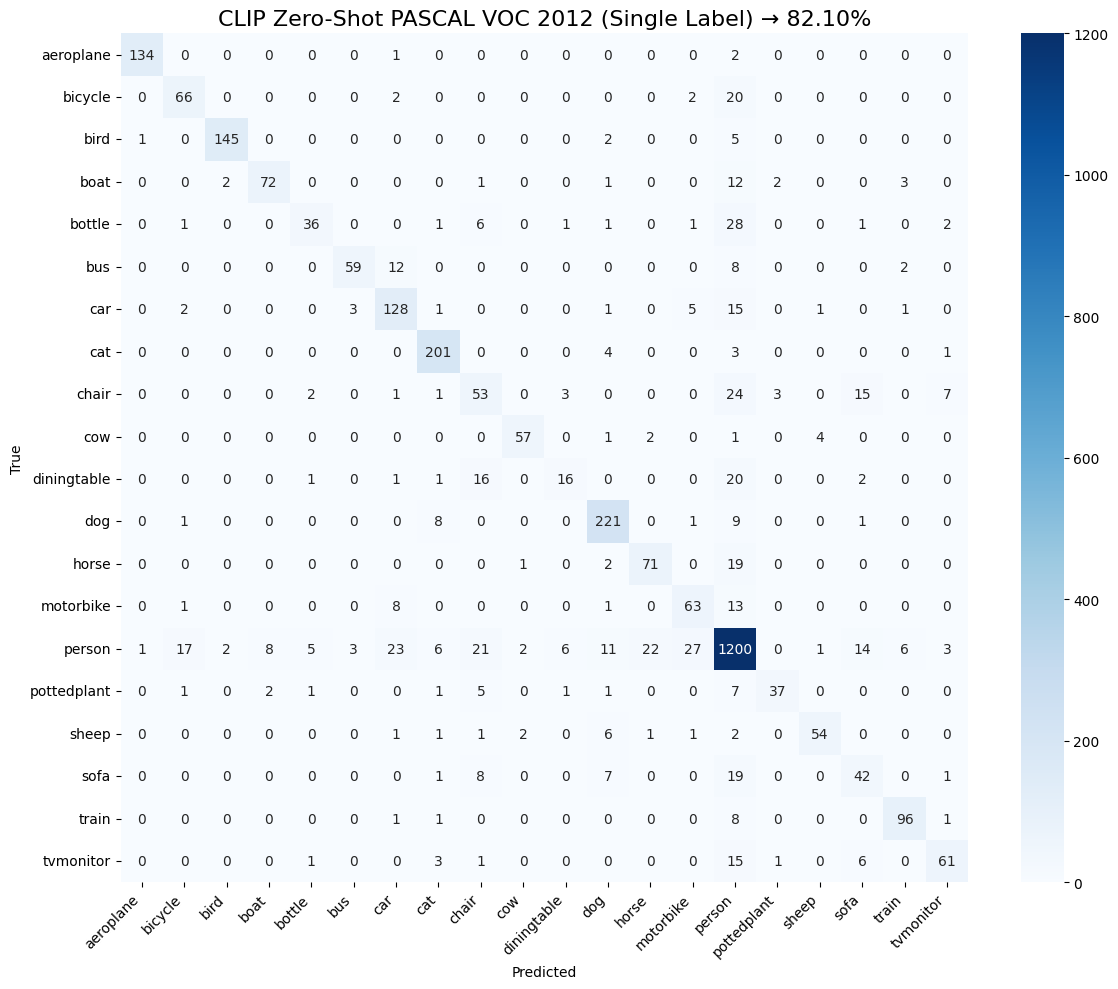

In [ ]:
# 12. Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title(f'CLIP Zero-Shot PASCAL VOC 2012 (Single Label) → {accuracy*100:.2f}%', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Assuming you already have:
# all_trues  → list or array of true labels (integer indices)
# all_preds  → list or array of predicted labels (integer indices)
# classes    → list of class names in the correct order

# Convert to numpy arrays if they aren't already
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Calculate precision, recall, f1-score for each class + averages
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds,
    labels=range(NUM_CLASSES),  # Ensure order matches 'classes'
    average=None,               # Per-class scores
    zero_division=0             # Avoid warnings for classes with no predictions
)

# Also compute macro and micro averages
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='macro', zero_division=0)
precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='micro', zero_division=0)

# Print detailed per-class results
print("\n" + "="*60)
print("PER-CLASS METRICS (Zero-Shot CLIP on PASCAL VOC 2012 Single-Label)")
print("="*60)
print(f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
print("-"*60)
for i, cls_name in enumerate(classes):
    print(f"{cls_name:<15} {precision[i]:<10.3f} {recall[i]:<10.3f} {f1[i]:<10.3f} {support[i]:<10}")

print("-"*60)
print(f"{'Macro Avg':<15} {precision_macro:<10.3f} {recall_macro:<10.3f} {f1_macro:<10.3f}")
print(f"{'Micro Avg':<15} {precision_micro:<10.3f} {recall_micro:<10.3f} {f1_micro:<10.3f}")
print(f"{'Accuracy':<15} {accuracy_score(all_labels, all_preds):<10.3f}")
print("="*60)




PER-CLASS METRICS (Zero-Shot CLIP on PASCAL VOC 2012 Single-Label)
Class           Precision  Recall     F1-Score   Support   
------------------------------------------------------------
aeroplane       0.985      0.978      0.982      137       
bicycle         0.742      0.733      0.737      90        
bird            0.973      0.948      0.960      153       
boat            0.878      0.774      0.823      93        
bottle          0.783      0.462      0.581      78        
bus             0.908      0.728      0.808      81        
car             0.719      0.815      0.764      157       
cat             0.889      0.962      0.924      209       
chair           0.473      0.486      0.480      109       
cow             0.919      0.877      0.898      65        
diningtable     0.593      0.281      0.381      57        
dog             0.853      0.917      0.884      241       
horse           0.740      0.763      0.751      93        
motorbike       0.630      0.73

In [ ]:
vit_total = count_params(image_encoder, trainable_only=False)
vit_trainable = count_params(image_encoder, trainable_only=True)

bert_total = count_params(text_encoder, trainable_only=False)
bert_trainable = count_params(text_encoder, trainable_only=True)

proj_total = count_params(image_projection, trainable_only=False)
proj_trainable = count_params(image_projection, trainable_only=True)

total_trainable = vit_trainable + proj_trainable + bert_trainable

print("\n================ MODEL PARAMETERS ================\n")

print(f"EMBED_DIM                  : {EMBED_DIM}")
print(f"BATCH_SIZE                 : 128 (effective 256 with accumulation=2)")
print(f"EPOCHS                     : 5")
print(f"Optimizer                  : AdamW")
print(f"Mixed Precision            : torch.cuda.amp + GradScaler")
print()

print("------ Image Encoder (ViT-Base / patch16_224) ------")
print(f"Hidden dim                 : 768")
print(f"Total params               : {vit_total/1e6:.2f} M")
print(f"Trainable params           : {vit_trainable/1e6:.2f} M")
print()

print("------ Text Encoder (BERT-base-uncased) ------")
print(f"Hidden dim                 : 768")
print(f"Total params               : {bert_total/1e6:.2f} M")
print(f"Trainable params           : {bert_trainable/1e6:.2f} M (FROZEN)")
print()

print("------ Image Projection (Linear 768 → 768) ------")
print(f"Weight params              : {EMBED_DIM * EMBED_DIM:,}")
print(f"Bias params                : {EMBED_DIM:,}")
print(f"Total params               : {proj_total:,}  ({proj_total/1e6:.3f} M)")
print()

print("------ LoRA ------")
print("LoRA Rank (r)               : N/A")
print("LoRA Alpha                 : N/A")
print()

print("====== TRAINABLE PARAMETER SUMMARY ======")
print(f"Trainable ViT              : {vit_trainable/1e6:.2f} M")
print(f"Trainable Projection       : {proj_trainable/1e6:.3f} M")
print(f"Trainable BERT             : {bert_trainable/1e6:.2f} M (frozen)")
print("-----------------------------------------")
print(f"TOTAL Trainable Params     : {total_trainable/1e6:.2f} M")
print("==========================================")


NameError: name 'count_params' is not defined

repeat

In [ ]:
import torch
import torch.nn as nn
from transformers import ViTForImageClassification, ViTImageProcessor
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import accuracy_score

# ─── 1. Load model with classification head ────────────────────────────────
vit_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(vit_name)

model = ViTForImageClassification.from_pretrained(
    vit_name,
    num_labels=len(classes),
    id2label={i: c for i, c in enumerate(classes)},
    label2id=class_to_idx,
    ignore_mismatched_sizes=True
).to(device)




preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([20])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([20, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
!pip install -U transformers
!pip install torch torchvision  # (with CUDA support for GPU)
!pip install open_clip_torch
!pip install pillow  # for image handlingV
!pip install -q --no-cache-dir open-clip-torch==2.24.0
